<a href="https://colab.research.google.com/github/yoghan007/dlv_exp/blob/main/CNN_for_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.9416 - loss: 0.1899 - val_accuracy: 0.9840 - val_loss: 0.0567
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 85s 55ms/step - accuracy: 0.9829 - loss: 0.0562 - val_accuracy: 0.9847 - val_loss: 0.0516
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.9873 - val_loss: 0.0374
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.9910 - loss: 0.0283 - val_accuracy: 0.9868 - val_loss: 0.0419
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9924 - loss: 0.0228 - val_accuracy: 0.9863 - val_loss: 0.0432
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9906 - loss: 0.0310
Test Accuracy: 99.06%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


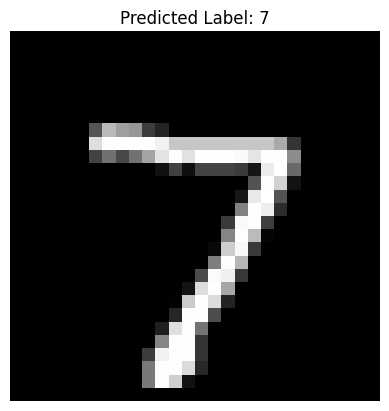

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
model = models.Sequential([
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
predictions = model.predict(x_test)
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted Label: {predictions[0].argmax()}")
plt.axis('off')
plt.show()